In [27]:
print("hello world")

hello world


In [28]:
import pandas as pd

In [29]:
import yfinance as yf

apple = yf.Ticker('AAPL')

data = apple.history(period='10y')

print(data)

                            Open   High    Low  Close     Volume  Dividends  \
Date                                                                          
2016-05-09 00:00:00-04:00  21.19  21.37  21.10  21.14  131745600       0.00   
2016-05-10 00:00:00-04:00  21.27  21.32  20.99  21.29  134747200       0.00   
2016-05-11 00:00:00-04:00  21.30  21.32  21.07  21.08  114876400       0.00   
2016-05-12 00:00:00-04:00  21.13  21.14  20.39  20.58  305258800       0.00   
2016-05-13 00:00:00-04:00  20.51  20.89  20.51  20.63  177571200       0.00   
...                          ...    ...    ...    ...        ...        ...   
2026-05-01 00:00:00-04:00 278.86 287.22 278.37 280.14   79915400       0.00   
2026-05-04 00:00:00-04:00 279.66 280.63 274.86 276.83   46668400       0.00   
2026-05-05 00:00:00-04:00 276.93 284.57 276.50 284.18   49311700       0.00   
2026-05-06 00:00:00-04:00 281.92 288.03 281.07 287.51   58336100       0.00   
2026-05-07 00:00:00-04:00 289.27 292.13 285.78 287.4

<function matplotlib.pyplot.show(close=None, block=None)>

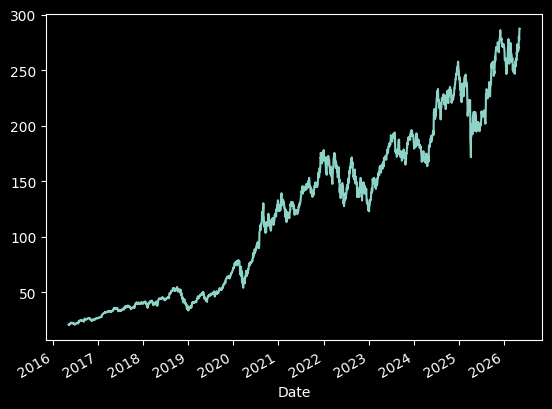

In [30]:
import matplotlib.pyplot as plt

data['Close'].plot()

plt.show

# Why did Apple's stock price rise so much between 2020 and 2026?

The most significant factors affecting a company's stock price are its company earnings and financial performance . These are some metrics that represent that:

- Revenue growth
- Profit margins
- Earnings per share (EPS)
- Cash flow
- Debt levels


## Let's begin with an analysis of Apple's revenue growth and why this may explain its stock price

In [31]:
apple.financials

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Tax Effect Of Unusual Items,0.00,0.00,0.00,0.00,NaN
Tax Rate For Calcs,0.16,0.24,0.15,0.16,NaN
Normalized EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
Net Income From Continuing Operation Net Minority Interest,"112,010,000,000.00","93,736,000,000.00","96,995,000,000.00","99,803,000,000.00",NaN
Reconciled Depreciation,"11,698,000,000.00","11,445,000,000.00","11,519,000,000.00","11,104,000,000.00",NaN
Reconciled Cost Of Revenue,"220,960,000,000.00","210,352,000,000.00","214,137,000,000.00","223,546,000,000.00",NaN
EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
EBIT,"133,050,000,000.00","123,216,000,000.00","114,301,000,000.00","119,437,000,000.00",NaN
Net Interest Income,NaN,NaN,"-183,000,000.00","-106,000,000.00","198,000,000.00"
Interest Expense,NaN,NaN,"3,933,000,000.00","2,931,000,000.00","2,645,000,000.00"


In [32]:

pd.options.display.float_format = '{:,.2f}'.format
revenue = apple.financials.loc['Total Revenue']
print(revenue)

2025-09-30   416,161,000,000.00
2024-09-30   391,035,000,000.00
2023-09-30   383,285,000,000.00
2022-09-30   394,328,000,000.00
2021-09-30                  NaN
Name: Total Revenue, dtype: float64


In [33]:
rev_growth = ((revenue.iloc[0] - revenue.iloc[3])/revenue.iloc[3])*100
print(rev_growth)

5.536761274877767


## Total revenue doesn't seem to have differed that drastically between 2022 and 2025.

There has only been a **5.5% growth rate** between 2025 and 2022.

Looking at profit margin next

In [34]:
net_income = apple.financials.loc['Net Income']
print(net_income)

profit_margin = net_income/revenue
print(profit_margin)

2025-09-30   112,010,000,000.00
2024-09-30    93,736,000,000.00
2023-09-30    96,995,000,000.00
2022-09-30    99,803,000,000.00
2021-09-30                  NaN
Name: Net Income, dtype: float64
2025-09-30   0.27
2024-09-30   0.24
2023-09-30   0.25
2022-09-30   0.25
2021-09-30    NaN
dtype: float64


## profit margins also look stable

- I may be jumping the gun here but what if apple's drastic growth doesn't have anything to do with its company financials...

<u>Next Step: </u>
I will look at its earnings per share, cash flow and debt levels and if there is no significant change in these metrics i will conclude that Apple's company financials are not the main cause for the change in stock price.

In [35]:
shares = apple.info['sharesOutstanding']
#EPS means earnings per share

eps = net_income/shares

print(eps)


2025-09-30   7.63
2024-09-30   6.38
2023-09-30   6.60
2022-09-30   6.80
2021-09-30    NaN
Name: Net Income, dtype: float64


EPS only showed a notable change between 2024 and 2025

In [42]:
# ocf is operating cash flow
cashflow = apple.cashflow
print(cashflow)


                                                        2025-09-30  \
Free Cash Flow                                   98,767,000,000.00   
Repurchase Of Capital Stock                     -90,711,000,000.00   
Repayment Of Debt                               -10,932,000,000.00   
Issuance Of Debt                                  4,481,000,000.00   
Issuance Of Capital Stock                                      NaN   
Capital Expenditure                             -12,715,000,000.00   
Interest Paid Supplemental Data                                NaN   
Income Tax Paid Supplemental Data                43,369,000,000.00   
End Cash Position                                35,934,000,000.00   
Beginning Cash Position                          29,943,000,000.00   
Changes In Cash                                   5,991,000,000.00   
Financing Cash Flow                            -120,686,000,000.00   
Cash Flow From Continuing Financing Activities -120,686,000,000.00   
Net Other Financing 

In [44]:
fcf = cashflow.loc["Free Cash Flow"]

fcf_margin = (fcf/revenue)*100

print(fcf_margin)

2025-09-30   23.73
2024-09-30   27.83
2023-09-30   25.98
2022-09-30   28.26
2021-09-30     NaN
dtype: float64


Free cash flow margin also seems to be the same

In [ ]:
operating_income =